In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve
)
import xgboost as xgb
import lightgbm as lgb
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Load processed data from Week 2
X_train = np.load('../data/processed/X_train_sm.npy')   # SMOTE-balanced
y_train = np.load('../data/processed/y_train_sm.npy')
X_test  = np.load('../data/processed/X_test_scaled.npy') # never touched
y_test  = np.load('../data/processed/y_test.npy')
feature_names = pd.read_csv('../data/processed/feature_names.csv').iloc[:, 0].tolist()

print(f"Train: {X_train.shape} | Fraud ratio: {y_train.mean()*100:.2f}%")
print(f"Test:  {X_test.shape}  | Fraud ratio: {y_test.mean()*100:.4f}%")
print(f"Features: {len(feature_names)}")

Train: (250196, 36) | Fraud ratio: 9.09%
Test:  (56962, 36)  | Fraud ratio: 0.1720%
Features: 36


In [2]:
def evaluate_model(name, model, X_test, y_test, threshold=0.5):
    """Full evaluation report for a fraud detection model."""
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred  = (y_proba >= threshold).astype(int)

    auc_roc = roc_auc_score(y_test, y_proba)
    auc_pr  = average_precision_score(y_test, y_proba)

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  AUC-ROC : {auc_roc:.4f}")
    print(f"  AUC-PR  : {auc_pr:.4f}   ← primary metric for fraud")
    print(f"\n{classification_report(y_test, y_pred, target_names=['Legit','Fraud'])}")

    return {'name': name, 'auc_roc': auc_roc, 'auc_pr': auc_pr,
            'model': model, 'y_proba': y_proba}


def plot_pr_roc(results_list):
    """Overlaid PR and ROC curves for all models."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ['#378ADD', '#7F77DD', '#1D9E75', '#E24B4A']

    for res, color in zip(results_list, colors):
        # PR curve
        prec, rec, _ = precision_recall_curve(y_test, res['y_proba'])
        axes[0].plot(rec, prec, color=color,
                     label=f"{res['name']} (AUC={res['auc_pr']:.3f})")
        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
        axes[1].plot(fpr, tpr, color=color,
                     label=f"{res['name']} (AUC={res['auc_roc']:.3f})")

    axes[0].set_title('Precision-Recall Curve')
    axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
    axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

    axes[1].plot([0,1],[0,1],'--', color='gray', alpha=0.5)
    axes[1].set_title('ROC Curve')
    axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
    axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('../notebooks/figures/pr_roc_curves.png', dpi=150)
    plt.show()

In [3]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_results = evaluate_model('Logistic Regression', lr, X_test, y_test)


  Logistic Regression
  AUC-ROC : 0.9682
  AUC-PR  : 0.6979   ← primary metric for fraud

              precision    recall  f1-score   support

       Legit       1.00      0.97      0.99     56864
       Fraud       0.05      0.91      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.94      0.54     56962
weighted avg       1.00      0.97      0.98     56962



In [4]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_results = evaluate_model('Random Forest', rf, X_test, y_test)


  Random Forest
  AUC-ROC : 0.9630
  AUC-PR  : 0.8800   ← primary metric for fraud

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.87      0.81      0.84        98

    accuracy                           1.00     56962
   macro avg       0.93      0.90      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [5]:
lgbm = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm.fit(X_train, y_train)
lgbm_results = evaluate_model('LightGBM', lgbm, X_test, y_test)


  LightGBM
  AUC-ROC : 0.9816
  AUC-PR  : 0.8564   ← primary metric for fraud

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.79      0.86      0.82        98

    accuracy                           1.00     56962
   macro avg       0.90      0.93      0.91     56962
weighted avg       1.00      1.00      1.00     56962



In [6]:
xgb_base = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_base.fit(X_train, y_train)
xgb_results = evaluate_model('XGBoost (base)', xgb_base, X_test, y_test)


  XGBoost (base)
  AUC-ROC : 0.9829
  AUC-PR  : 0.8778   ← primary metric for fraud

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.72      0.88      0.79        98

    accuracy                           1.00     56962
   macro avg       0.86      0.94      0.89     56962
weighted avg       1.00      1.00      1.00     56962



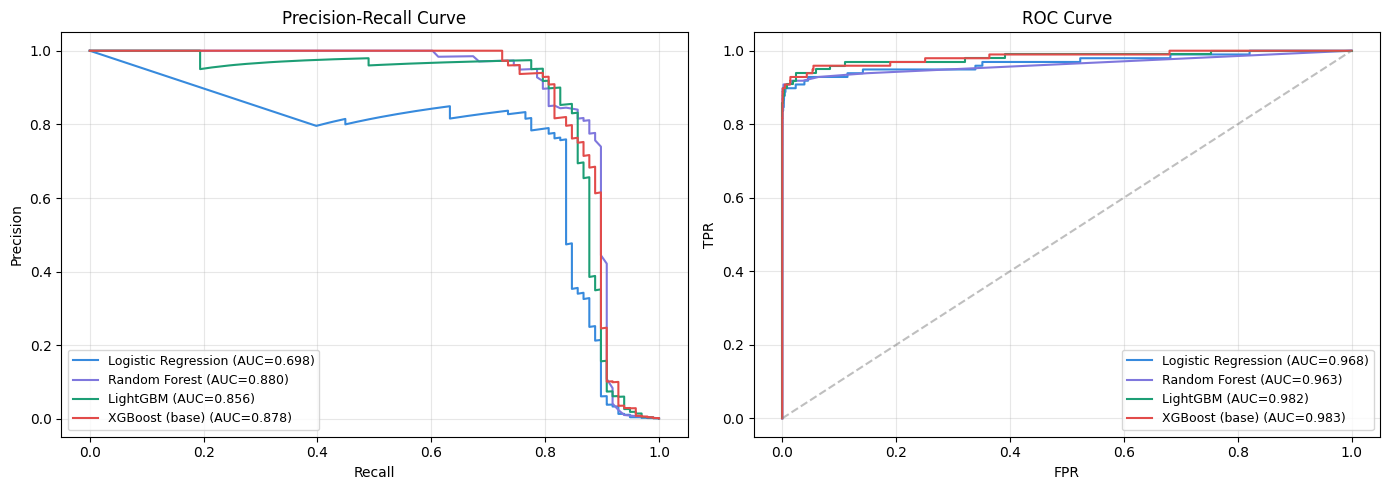


Model comparison:
              Model  AUC-ROC  AUC-PR
      Random Forest   0.9630  0.8800
     XGBoost (base)   0.9829  0.8778
           LightGBM   0.9816  0.8564
Logistic Regression   0.9682  0.6979


In [7]:
all_results = [lr_results, rf_results, lgbm_results, xgb_results]
plot_pr_roc(all_results)

# Summary table
summary = pd.DataFrame([
    {'Model': r['name'], 'AUC-ROC': round(r['auc_roc'], 4),
     'AUC-PR': round(r['auc_pr'], 4)}
    for r in all_results
]).sort_values('AUC-PR', ascending=False)
print("\nModel comparison:")
print(summary.to_string(index=False))

In [8]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 200, 800),
        'max_depth':        trial.suggest_int('max_depth', 3, 9),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma':            trial.suggest_float('gamma', 0, 0.5),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0, 1.0),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0.5, 2.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 50, 200),
        'eval_metric': 'aucpr',
        'random_state': 42,
        'verbosity': 0,
        'n_jobs': -1,
    }
    model = xgb.XGBClassifier(**params)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(
        model, X_train, y_train,
        cv=cv, scoring='average_precision', n_jobs=-1
    )
    return scores.mean()

print("Running Optuna (50 trials)... this takes ~5 mins")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest AUC-PR (CV): {study.best_value:.4f}")
print(f"Best params:\n{study.best_params}")

Running Optuna (50 trials)... this takes ~5 mins


Best trial: 47. Best value: 0.99997: 100%|██████| 50/50 [10:20<00:00, 12.41s/it]


Best AUC-PR (CV): 1.0000
Best params:
{'n_estimators': 430, 'max_depth': 6, 'learning_rate': 0.17589880945126427, 'subsample': 0.8495048533063884, 'colsample_bytree': 0.7328540695969258, 'min_child_weight': 3, 'gamma': 0.12617614050853077, 'reg_alpha': 0.48373250639366194, 'reg_lambda': 0.9881049827622178, 'scale_pos_weight': 77.93613283096647}


In [9]:
best_params = study.best_params
best_params.update({'eval_metric': 'aucpr', 'random_state': 42,
                    'verbosity': 0, 'n_jobs': -1})

xgb_tuned = xgb.XGBClassifier(**best_params)
xgb_tuned.fit(X_train, y_train)

xgb_tuned_results = evaluate_model('XGBoost (tuned)', xgb_tuned, X_test, y_test)

# Compare base vs tuned
print(f"\nImprovement from tuning:")
print(f"  AUC-PR:  {xgb_results['auc_pr']:.4f} → {xgb_tuned_results['auc_pr']:.4f}  (+{xgb_tuned_results['auc_pr']-xgb_results['auc_pr']:.4f})")
print(f"  AUC-ROC: {xgb_results['auc_roc']:.4f} → {xgb_tuned_results['auc_roc']:.4f}  (+{xgb_tuned_results['auc_roc']-xgb_results['auc_roc']:.4f})")


  XGBoost (tuned)
  AUC-ROC : 0.9769
  AUC-PR  : 0.8849   ← primary metric for fraud

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.80      0.88      0.84        98

    accuracy                           1.00     56962
   macro avg       0.90      0.94      0.92     56962
weighted avg       1.00      1.00      1.00     56962


Improvement from tuning:
  AUC-PR:  0.8778 → 0.8849  (+0.0071)
  AUC-ROC: 0.9829 → 0.9769  (+-0.0060)


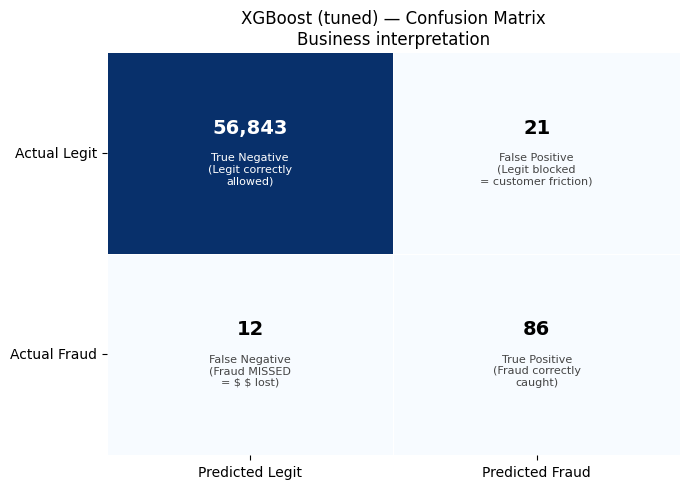


Business impact:
  Fraud caught:   86/98 = 87.8% recall
  False alarms:   21 legit transactions incorrectly blocked
  Fraud missed:   12 fraudulent transactions slipped through


In [11]:
from sklearn.metrics import confusion_matrix
import matplotlib.patches as mpatches

y_proba = xgb_tuned.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', ax=ax,
            linewidths=0.5, cbar=False)

# Annotate with business language
labels = [
    ['True Negative\n(Legit correctly\nallowed)', 'False Positive\n(Legit blocked\n= customer friction)'],
    ['False Negative\n(Fraud MISSED\n= \$ \$ lost)',  'True Positive\n(Fraud correctly\ncaught)']
]
for i in range(2):
    for j in range(2):
        ax.text(j+0.5, i+0.4, f'{cm[i,j]:,}',
                ha='center', fontsize=14, fontweight='bold', color='white' if cm[i,j] > cm.max()/2 else 'black')
        ax.text(j+0.5, i+0.65, labels[i][j],
                ha='center', fontsize=8, color='white' if cm[i,j] > cm.max()/2 else '#444')

ax.set_xticklabels(['Predicted Legit', 'Predicted Fraud'])
ax.set_yticklabels(['Actual Legit', 'Actual Fraud'], rotation=0)
ax.set_title('XGBoost (tuned) — Confusion Matrix\nBusiness interpretation')
plt.tight_layout()
plt.savefig('../notebooks/figures/confusion_matrix.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nBusiness impact:")
print(f"  Fraud caught:   {tp}/{tp+fn} = {tp/(tp+fn)*100:.1f}% recall")
print(f"  False alarms:   {fp} legit transactions incorrectly blocked")
print(f"  Fraud missed:   {fn} fraudulent transactions slipped through")

 threshold  precision  recall  false_positives  fraud_missed
      0.10      0.607   0.898               57            10
      0.15      0.672   0.898               43            10
      0.20      0.715   0.898               35            10
      0.25      0.727   0.898               33            10
      0.30      0.765   0.898               27            10
      0.35      0.765   0.898               27            10
      0.40      0.791   0.888               23            11
      0.45      0.798   0.888               22            11
      0.50      0.804   0.878               21            12
      0.55      0.808   0.857               20            14
      0.60      0.814   0.847               19            15
      0.65      0.814   0.847               19            15
      0.70      0.822   0.847               18            15
      0.75      0.830   0.847               17            15
      0.80      0.845   0.837               15            16
      0.85      0.862   

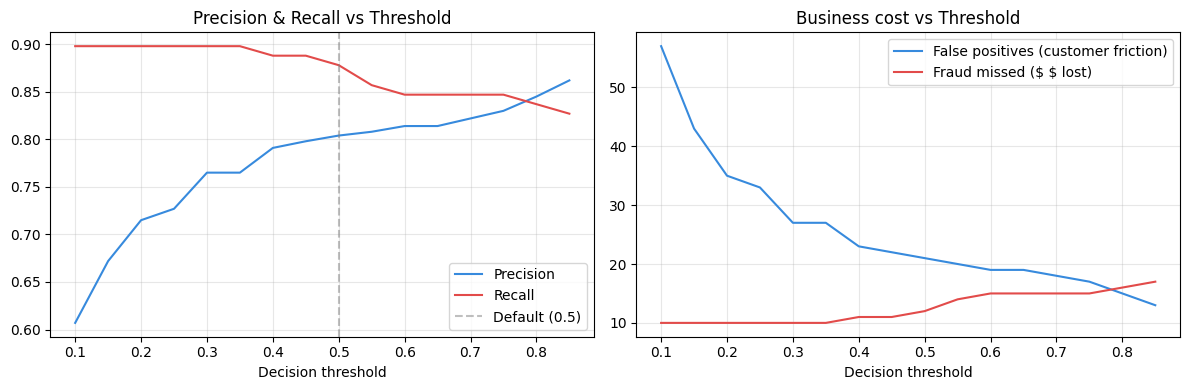

In [13]:
thresholds = np.arange(0.1, 0.9, 0.05)
rows = []
for t in thresholds:
    y_p = (y_proba >= t).astype(int)
    cm_t = confusion_matrix(y_test, y_p)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    precision = tp_t / (tp_t + fp_t + 1e-9)
    recall    = tp_t / (tp_t + fn_t + 1e-9)
    rows.append({'threshold': round(t, 2), 'precision': round(precision, 3),
                 'recall': round(recall, 3), 'false_positives': fp_t, 'fraud_missed': fn_t})

thresh_df = pd.DataFrame(rows)
print(thresh_df.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(thresh_df['threshold'], thresh_df['precision'], color='#378ADD', label='Precision')
axes[0].plot(thresh_df['threshold'], thresh_df['recall'], color='#E24B4A', label='Recall')
axes[0].axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='Default (0.5)')
axes[0].set_title('Precision & Recall vs Threshold')
axes[0].set_xlabel('Decision threshold'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(thresh_df['threshold'], thresh_df['false_positives'], 
             color='#378ADD', label='False positives (customer friction)')
axes[1].plot(thresh_df['threshold'], thresh_df['fraud_missed'],    
             color='#E24B4A', label='Fraud missed (\$ \$ lost)')
axes[1].set_title('Business cost vs Threshold')
axes[1].set_xlabel('Decision threshold'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/figures/threshold_analysis.png', dpi=150)
plt.show()

Computing SHAP values (takes ~1 min)...


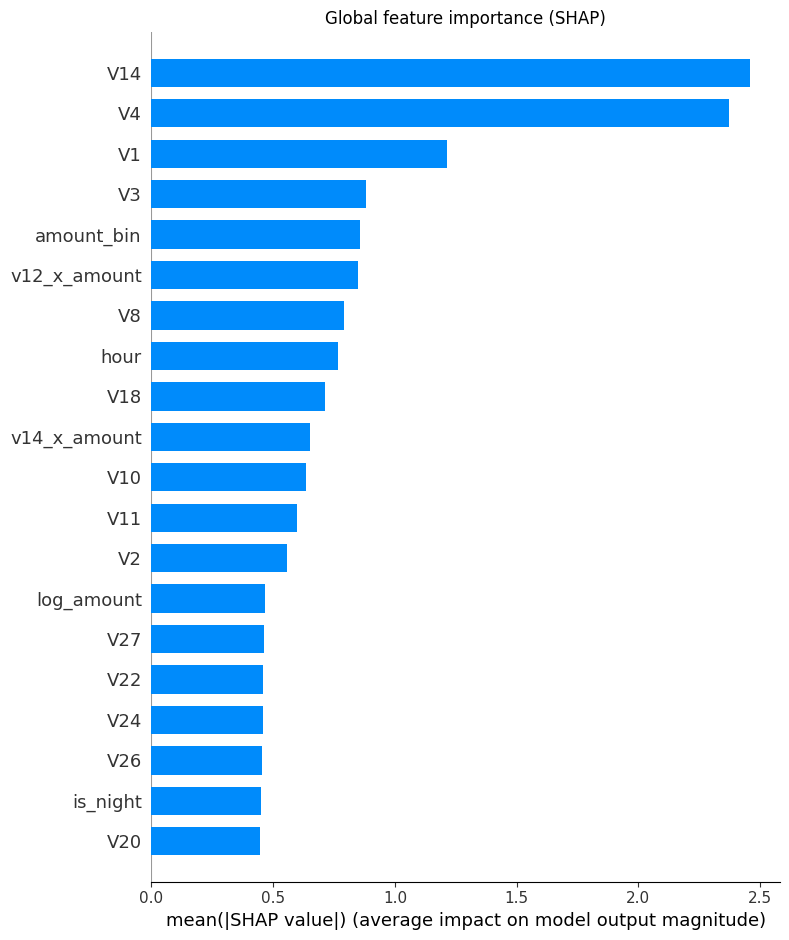

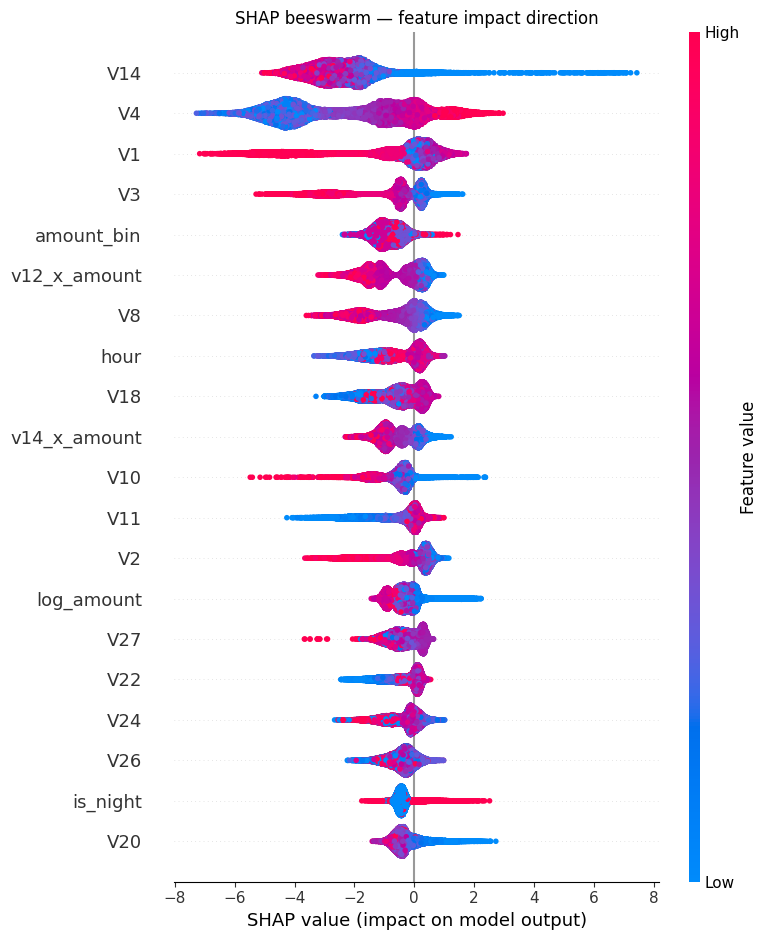

In [14]:
print("Computing SHAP values (takes ~1 min)...")
explainer  = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_test)

# Global feature importance
plt.figure()
shap.summary_plot(shap_values, X_test,
                  feature_names=feature_names,
                  plot_type='bar', show=False)
plt.title('Global feature importance (SHAP)')
plt.tight_layout()
plt.savefig('../notebooks/figures/shap_global.png', dpi=150, bbox_inches='tight')
plt.show()

# Beeswarm — shows direction of impact
plt.figure()
shap.summary_plot(shap_values, X_test,
                  feature_names=feature_names,
                  show=False)
plt.title('SHAP beeswarm — feature impact direction')
plt.tight_layout()
plt.savefig('../notebooks/figures/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

Explaining transaction #7299
  True label:       FRAUD
  Fraud probability: 1.0000


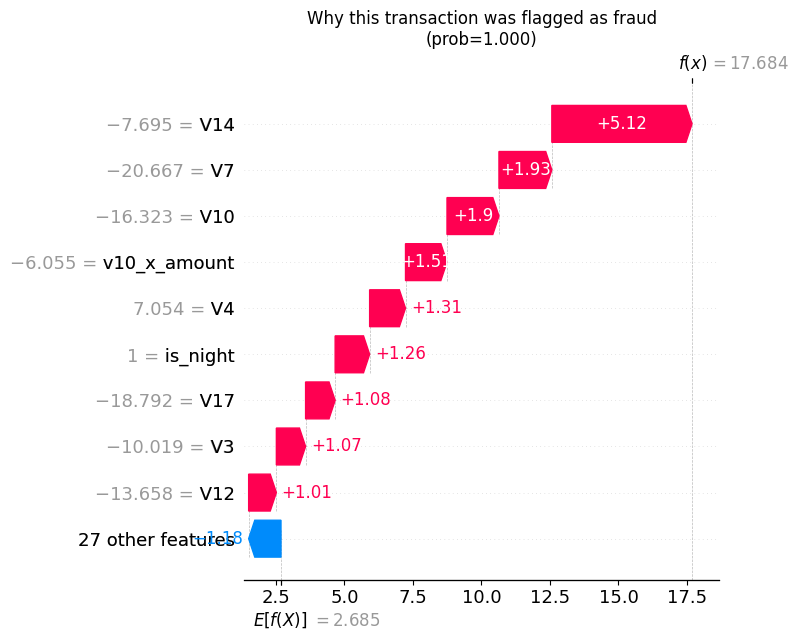

In [15]:
# Find a high-confidence fraud prediction to explain
fraud_indices = np.where(y_test == 1)[0]
high_conf_idx = fraud_indices[
    np.argmax(y_proba[fraud_indices])   # highest fraud probability
]

print(f"Explaining transaction #{high_conf_idx}")
print(f"  True label:       {'FRAUD' if y_test[high_conf_idx]==1 else 'LEGIT'}")
print(f"  Fraud probability: {y_proba[high_conf_idx]:.4f}")

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_conf_idx],
        base_values=explainer.expected_value,
        data=X_test[high_conf_idx],
        feature_names=feature_names
    ),
    show=False
)
plt.title(f'Why this transaction was flagged as fraud\n(prob={y_proba[high_conf_idx]:.3f})')
plt.tight_layout()
plt.savefig('../notebooks/figures/shap_waterfall_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
import joblib, json
from pathlib import Path

Path('../models').mkdir(exist_ok=True)

# Save model
joblib.dump(xgb_tuned, '../models/xgb_fraud_v1.pkl')

# Save best params and metrics for MLflow (Week 4)
metrics = {
    'auc_roc': round(xgb_tuned_results['auc_roc'], 4),
    'auc_pr':  round(xgb_tuned_results['auc_pr'], 4),
    'threshold': 0.5
}
params = study.best_params

with open('../models/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
with open('../models/best_params.json', 'w') as f:
    json.dump(params, f, indent=2)

print("Saved:")
print("  ../models/xgb_fraud_v1.pkl")
print("  ../models/metrics.json")
print("  ../models/best_params.json")
print(f"\nFinal model performance:")
print(f"  AUC-ROC : {metrics['auc_roc']}")
print(f"  AUC-PR  : {metrics['auc_pr']}")

Saved:
  ../models/xgb_fraud_v1.pkl
  ../models/metrics.json
  ../models/best_params.json

Final model performance:
  AUC-ROC : 0.9769
  AUC-PR  : 0.8849
